#### Imports & Setups

In [1]:
import os
import yaml
import operator
from pathlib import Path
from rich.align import Align
from rich.pretty import Pretty
from dotenv import load_dotenv
from rich.markdown import Markdown
from langgraph_utils import console
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langchain_core.prompts import ChatPromptTemplate
from typing import TypedDict, List, Annotated, Literal
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.output_parsers import StrOutputParser

prompt_config = yaml.safe_load(Path("configs/prompts.yaml").read_text())
params_config = yaml.safe_load(Path("configs/params.yaml").read_text())

load_dotenv()

True

#### Model

In [2]:
def get_llm(model: str = "gemini-2.5-flash", temperature: float = 0.7, max_output_tokens: int = 1000):
    llm = ChatGoogleGenerativeAI(
        model=model,
        temperature=temperature,
        max_output_tokens=max_output_tokens,
    )

    return llm


#### State

In [3]:
class ResponseState(TypedDict):
    query: str

    response: str
    reflection: str
    implementation_plan: str

    max_iterations: int
    current_iteration: int
    is_satisfactory: Literal[True, False]

    response_history: Annotated[List[str], operator.add]
    reflection_history: Annotated[List[str], operator.add]
    plan_history: Annotated[List[str], operator.add]


#### Nodel & Helper Functions

Response Generation

In [4]:
def generate_response(state: ResponseState):

    generation_prompt = ChatPromptTemplate.from_messages(
        [
            ("system", prompt_config["generate_response"]["system_prompt"]),
            ("user", prompt_config["generate_response"]["user_prompt"]),
        ]
    )

    generation_model = get_llm(**params_config["generation_model"])
    generation_parser = StrOutputParser()

    chain = generation_prompt | generation_model | generation_parser
    res = chain.invoke(
        {
            "query": state["query"],
            "iteration": state["current_iteration"],
            "response": state.get("response", ""),
            "reflection": state.get("reflection", ""),
        }
    )

    return {
        "response": res,
        "response_history": [res],
        "current_iteration": state["current_iteration"] + 1,
    }


Evaluation Output Schema

In [5]:
class EvaluationSchema(BaseModel):
    is_satisfactory: Literal[True, False] = Field(description=params_config["EvaluationSchema"]["is_satisfactory_description"])
    reflection: str = Field(description=params_config["EvaluationSchema"]["reflection_description"])

Response Evaluation

In [6]:
def evaluate_response(state: ResponseState):
    evaluation_prompt = ChatPromptTemplate(
        [
            ("system", prompt_config["evaluate_response"]["system_prompt"]),
            ("user", prompt_config["evaluate_response"]["user_prompt"]),
        ]
    )

    evaluation_model = get_llm(**params_config["evaluation_model"])
    structured_evaluation_model = evaluation_model.with_structured_output(EvaluationSchema)

    chain = evaluation_prompt | structured_evaluation_model
    res = chain.invoke(
        {
            "query": state["query"],
            "response": state["response"],
        }
    )

    return {
        "is_satisfactory": res.is_satisfactory,
        "reflection": res.reflection,
        "reflection_history": [res.reflection],
    }

Optimization Planning

In [7]:
def plan_optimization(state: ResponseState):
    optimization_prompt = ChatPromptTemplate(
        [
            ("system", prompt_config["plan_optimization"]["system_prompt"]),
            ("user", prompt_config["plan_optimization"]["user_prompt"]),
        ]
    )

    optimization_model = get_llm(**params_config["optimization_model"])
    optimization_parser = StrOutputParser()

    chain = optimization_prompt | optimization_model | optimization_parser
    res = chain.invoke(
        {
            "query": state["query"],
            "response": state["response"],
            "reflection": state["reflection"],
        }
    )

    return {
        "implementation_plan": res,
        "plan_history": [res],
    }


Optimization Routing

In [8]:
def route_optimization(state: ResponseState) -> Literal["finalize", "optimize"]:
    if state["is_satisfactory"] or state["current_iteration"] >= state["max_iterations"]:
        return "finalize"

    return "optimize"


#### Init Graph

In [9]:
graph = StateGraph(ResponseState)


#### Add Nodes

In [10]:
graph.add_node("generate_response", generate_response)
graph.add_node("evaluate_response", evaluate_response)
graph.add_node("plan_optimization", plan_optimization)

#### Add Edges

In [11]:
graph.add_edge(START, "generate_response")
graph.add_edge("generate_response", "evaluate_response")
graph.add_conditional_edges("evaluate_response", route_optimization, {"finalize": END, "optimize": "plan_optimization"})

graph.add_edge("plan_optimization", "generate_response")

#### Compilation

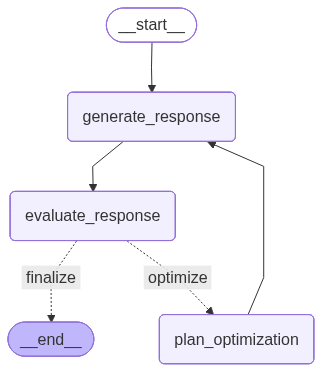

In [12]:
workflow = graph.compile()
workflow

#### Execution

In [13]:
final_state = workflow.invoke(
    {
        "query": "Andromeda Paradox",
        "max_iterations": 5,
        "current_iteration": 0,
    }
)

In [14]:
console.print_json(data={k: v for k, v in final_state.items() if k in ["query", "max_iterations", "current_iteration", "is_satisfactory"]})

{
  "query": "Andromeda Paradox",
  "max_iterations": 5,
  "current_iteration": 3,
  "is_satisfactory": true
}


In [15]:
console.print(Markdown(final_state["response"]))

The "Andromeda Paradox" is a well-known thought experiment in physics and philosophy that highlights one of the most    
counter-intuitive implications of Albert Einstein's Special Theory of Relativity: the relativity of simultaneity. It    
does not refer to the future collision of the Milky Way and Andromeda galaxies, nor is it primarily a concept from      
science fiction.                                                                                                        

Here's an explanation of the actual Andromeda Paradox:                                                                  

 1 Relativity of Simultaneity: In Special Relativity, there is no absolute "present moment" or "now" that applies       
   universally across the cosmos. Whether two events are simultaneous depends on the observer's frame of reference. This
   is because simultaneity is determined by measurements involving the finite speed of light, and measurements of time  
   and space are altered by re

In [16]:
console.print(Markdown(final_state["reflection"]))


The response is exceptionally accurate, clear, and comprehensive. It correctly explains the physics behind the Andromeda
Paradox (the relativity of simultaneity and Lorentz transformations), provides a mathematically sound description of the
thought experiment (where a walking speed of ~1 m/s translates to a ~2.5 to 3-day shift at Andromeda's distance), and   
accurately contextualizes its philosophical implications (the Rietdijk-Putnam argument, Roger Penrose's formulation, and
the block universe theory). No improvements are needed.                                                                 


In [17]:
console.print(Markdown(final_state["implementation_plan"]))


Based on the reviewer's feedback, here is the checklist to correct the quantitative error in the current answer:        

 • [ ] Correct the time-difference scale in Section 3 (The "Paradoxical" Implication, third bullet point):              
    • Change the phrase "millions of years before" and "millions of years after" to a realistic timeframe for walking   
      speeds.                                                                                                           
    • Specify that for two people walking past each other at normal walking speeds (approx. 1 m/s), the difference in   
      their "present moments" at the distance of the Andromeda galaxy is only about a few days (approximately 2.5 to 3  
      days), not millions of years.                                                                                     
 • [ ] Maintain the rest of the structure and content: Keep the explanations of the relativity of simultaneity, the     
   setup of the thought experim

In [22]:
for i, response in enumerate(final_state["response_history"]):
    print("_" * 120)
    console.print(Align.center(Pretty(f"Response {i + 1}")))

    console.print("\n", Markdown(response))
    print("_" * 120, end="\n\n")

________________________________________________________________________________________________________________________
                                                      'Response 1'                                                      


The "Andromeda Paradox" is not a widely recognized scientific paradox, but rather a concept popularized by the British  
science fiction television series Doctor Who.                                                                           

In the context of Doctor Who, the Andromeda Paradox refers to the idea that the Doctor, an ancient time traveler, might 
be able to witness the collision of the Milky Way galaxy with the Andromeda galaxy from a safe vantage point in the     
distant future. The paradox arises from the Doctor's unique perspective outside of normal time and space, allowing him  
to observe events that would typically unfold over billions of years. It highlights the vast scale of cosmic events and 
the Doctor's extraordinary li

In [23]:
for i, response in enumerate(final_state["reflection_history"]):
    print("_" * 120)
    console.print(Align.center(Pretty(f"Reflection {i + 1}")))

    console.print("\n", Markdown(response))
    print("_" * 120, end="\n\n")


________________________________________________________________________________________________________________________
                                                     'Reflection 1'                                                     


The response is factually incorrect. The 'Andromeda Paradox' is a well-known physical and philosophical thought         
experiment concerning the relativity of simultaneity in special relativity, famously discussed by Roger Penrose in his  
book 'The Emperor's New Mind' (building on the Rietdijk-Putnam argument). It describes how two observers walking past   
each other on Earth can have different 'present' states for the Andromeda galaxy (e.g., one observer's present includes 
an alien space fleet launching, while the other's present does not). The response completely misses this actual         
scientific concept and instead attributes the term to a fictional narrative device in 'Doctor Who' regarding the Milky  
Way-Andromeda collision, which

In [24]:
for i, response in enumerate(final_state["plan_history"]):
    print("_" * 120)
    console.print(Align.center(Pretty(f"Plan {i + 1}")))

    console.print("\n", Markdown(response))
    print("_" * 120, end="\n\n")


________________________________________________________________________________________________________________________
                                                        'Plan 1'                                                        


Based on the reviewer's feedback, the current answer is factually incorrect and must be completely rewritten. Here is   
the checklist of actions required to correct the response:                                                              

Revision Checklist                                                                                                      

 1 Remove Incorrect Information:                                                                                        
    • [ ] Delete all references to Doctor Who.                                                                          
    • [ ] Remove the explanation of the physical collision between the Milky Way and Andromeda galaxies as the          
      definition of the para

In [21]:
os.makedirs("files", exist_ok=True)
with open("files/response.md", "w") as f:
    f.write(final_state["response"])
